# 05 · Power analysis and MDE

**Question:** before spending on a test, can a 6-state, 4-week design detect the lift the business expects, and which levers improve it?

**Answer:** the design's **MDE is 6%** (power ≥ 80%). A 2% expected lift has only **14%** power; adding states helps with diminishing returns (even 17 states reach only 42% at 2%), and a longer test helps only if the before/after windows stay comparable: 32 days was *worse* than 28.

**Method:** simulate experiments on **historical data only** (the 64 days before 2021-01-04): pick random treated states, inject a known lift into a fake test window, re-estimate with DiD 300 times. Power = share of estimates beyond the 95th percentile of the zero-lift estimates. **MDE** = smallest lift with power ≥ 80%.

**Data:** GA4 Google Merchandise Store public sample, sessions per US state per day; 34 states with ≥ 10 median sessions/day.

In [1]:
import pandas as pd, numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv("data/ga4_state_daily.csv", parse_dates=["date"])
REAL_START = pd.Timestamp("2021-01-04")

wide = df.pivot(index="date", columns="state", values="sessions").fillna(0).astype(float)
daily_median = df.groupby("state").sessions.median()
wide = wide[daily_median[daily_median >= 10].index]

hist = wide[wide.index < REAL_START]     # historical data only: 64 days
STATES = list(hist.columns)

def windows(test_days):
    """Fake test = last `test_days` of hist; fake before = the same number of days right before it."""
    fake_start = hist.index[-1] - pd.Timedelta(days=test_days - 1)
    before = (hist.index >= fake_start - pd.Timedelta(days=test_days)) & (hist.index < fake_start)
    after  = hist.index >= fake_start
    return before, after

def did_lift(data, treated, control, before, after):
    T = data[treated].sum(axis=1); C = data[control].sum(axis=1)
    return (T[after].sum() / T[before].sum()) / (C[after].sum() / C[before].sum()) - 1

before, after = windows(28)
print(f"{len(STATES)} states | fake before: {hist.index[before][0].date()} → {hist.index[before][-1].date()} "
      f"| fake test: {hist.index[after][0].date()} → {hist.index[after][-1].date()}")

34 states | fake before: 2020-11-09 → 2020-12-06 | fake test: 2020-12-07 → 2021-01-03


## Step 1 · One simulated experiment

Three random draws of 6 states with the same true 6% lift give 7.0%, 7.4%, and 5.3% (seeds 1–3). A real test is one such draw, which is why the design is judged across many draws.

In [2]:
rng = np.random.default_rng(1)        # seeds 1, 2, 3 give 7.0%, 7.4%, 5.3%
treated = list(rng.choice(STATES, 6, replace=False))
control = [s for s in STATES if s not in treated]

Y = hist.copy()
Y.loc[after, treated] *= 1.06          # true lift = 6%
print(treated)
print(f"Estimated lift: {did_lift(Y, treated, control, before, after):.1%}   (truth: 6%)")

['Ohio', 'Michigan', 'Utah', 'Maryland', 'Connecticut', 'Arizona']
Estimated lift: 7.0%   (truth: 6%)


## Step 2 · Power curve for 6 states × 28 days

In [3]:
def simulate(n_treated, lift, test_days, sims=300, seed=0):
    rng = np.random.default_rng(seed)
    before, after = windows(test_days)
    estimates = []
    for _ in range(sims):
        treated = list(rng.choice(STATES, n_treated, replace=False))     # n_treated random states
        control = [s for s in STATES if s not in treated]     # all other states
        Y = hist.copy()
        Y.loc[after, treated] *= 1 + lift     # inject the lift
        estimates.append(did_lift(Y, treated, control, before, after))
    return np.array(estimates)

def power(n_treated, lift, test_days):
    null = simulate(n_treated, 0, test_days, seed=1)
    critical = np.quantile(np.abs(null), 0.95)
    estimates = simulate(n_treated, lift, test_days, seed=2)
    return np.mean(np.abs(estimates) > critical)

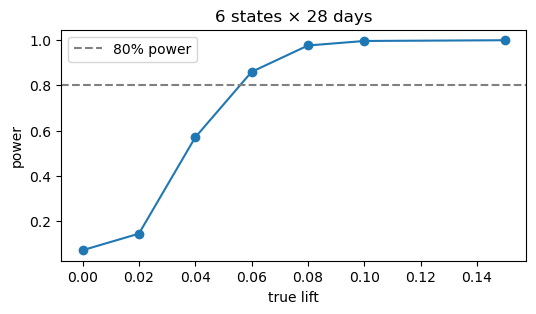

{'0%': 0.07, '2%': 0.14, '4%': 0.57, '6%': 0.86, '8%': 0.98, '10%': 1.0, '15%': 1.0}
MDE (≥ 80% power): 6%


In [4]:
LIFTS = [0, 0.02, 0.04, 0.06, 0.08, 0.10, 0.15]
curve = {lift: power(6, lift, 28) for lift in LIFTS}

plt.figure(figsize=(6, 3))
plt.plot(list(curve), list(curve.values()), "o-")
plt.axhline(0.8, ls="--", c="gray", label="80% power")
plt.xlabel("true lift"); plt.ylabel("power"); plt.title("6 states × 28 days"); plt.legend(); plt.show()

mde = next((lift for lift in LIFTS if curve[lift] >= 0.8), None)
print({f"{k:.0%}": round(v, 2) for k, v in curve.items()})
print(f"MDE (≥ 80% power): {mde:.0%}")

Sanity check: power at 0% lift ≈ 5–7%, the false-positive rate set by p < 0.05 (not exactly 5% with 300 simulations).

## Step 3 · Lever 1: more treated states

In [5]:
def mde_for(n_treated, test_days):
    curve = {lift: power(n_treated, lift, test_days) for lift in LIFTS}
    return next((lift for lift in LIFTS if curve[lift] >= 0.8), None), curve

for n in [3, 6, 10, 15]:
    mde, curve = mde_for(n, 28)
    print(f"{n:>2} states: MDE {mde:.0%} | power at 2%: {curve[0.02]:.2f}, 4%: {curve[0.04]:.2f}")

 3 states: MDE 8% | power at 2%: 0.09, 4%: 0.30
 6 states: MDE 6% | power at 2%: 0.14, 4%: 0.57
10 states: MDE 6% | power at 2%: 0.35, 4%: 0.79
15 states: MDE 4% | power at 2%: 0.36, 4%: 0.88


## Step 4 · Lever 2: longer test

In [6]:
for days in [14, 21, 28, 32]:
    mde, curve = mde_for(6, days)
    b, a = windows(days)
    print(f"{days} days (before starts {hist.index[b][0].date()}): MDE {mde:.0%} | power at 4%: {curve[0.04]:.2f}, 6%: {curve[0.06]:.2f}")

14 days (before starts 2020-12-07): MDE 10% | power at 4%: 0.28, 6%: 0.52
21 days (before starts 2020-11-23): MDE 8% | power at 4%: 0.31, 6%: 0.63
28 days (before starts 2020-11-09): MDE 6% | power at 4%: 0.57, 6%: 0.86
32 days (before starts 2020-11-01): MDE 8% | power at 4%: 0.40, 6%: 0.73


## Findings

**Power curve (6 states × 28 days)**

| True lift | 0% | 2% | 4% | 6% | 8% | 10% | 15% |
|---|---|---|---|---|---|---|---|
| Power | 0.07 | 0.14 | 0.57 | **0.86** | 0.98 | 1.00 | 1.00 |

**More treated states (28 days)**

| States | Predicted MDE = 6% × √(6/n) | MDE | Power at 2% |
|---|---|---|---|
| 3 | 8.5% | 8% | 0.09 |
| 6 | 6% | 6% | 0.14 |
| 10 | 4.6% | ≈ 4–5%\* | 0.35 |
| 15 | 3.8% | 4% | 0.36 |
| 17 (half of all) | | | 0.42 |

\* power 0.79 at 4% and 0.91 at 5%; the 2-point lift grid shows it as 6%.

- The 1/√n rule predicts the MDE well, with **diminishing returns**: +3 states (3→6) gains as much as +9 (6→15). More treated states also cost more and leave fewer controls.

**Longer test (6 states)**

| Days | Before → after windows | National change | Noise (std) | MDE |
|---|---|---|---|---|
| 14 | 12/07–12/20 → 12/21–01/03 | −41% | 2.8% | 10% |
| 21 | 11/23–12/13 → 12/14–01/03 | −22% | 2.6% | 8% |
| **28** | 11/09–12/06 → 12/07–01/03 | **+6%** | **1.8%** | **6%** |
| 32 | 11/01–12/02 → 12/03–01/03 | +11% | 2.2% | 8% |

- **32 days was worse than 28.** Noise depends on how comparable the windows are, not just on length. Big seasonal swings make states react differently, which weakens parallel trends.

## Recommendation

For an expected lift of 2%, a 6-state, 4-week test has 14% power, so it would most likely come back "not significant" even if the campaign works. A bigger test doesn't fix it (10 states: 35%; 17 states: 42%).

1. **Raise spend intensity** in the test states so the expected lift is ≥ 5%, then run **10 states × 4 weeks** (power ≈ 0.91 at 5%).
2. **Avoid Q4**: holiday swings inflate noise.
3. **Re-run the power analysis on a full year of history.**

If the effect really is ~2%, don't run this test: an inconclusive result costs budget and is easily misread as "the ads don't work."